In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

In [3]:
import pandas as pd

MATCH_KEYS = ['video_id', 'comment']

# Kiểm tra file Anchor (7B)
df_7b = pd.read_csv("test_result_7B.csv")
print("Số dòng trùng lặp trong 7B:", df_7b.duplicated(subset=MATCH_KEYS).sum())

# Kiểm tra file Ground Truth
df_gt = pd.read_csv("/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/data/gold/gold_Qwen3.7_max.csv")
print("Số dòng trùng lặp trong GT:", df_gt.duplicated(subset=MATCH_KEYS).sum())

Số dòng trùng lặp trong 7B: 5
Số dòng trùng lặp trong GT: 1322


In [4]:
MATCH_KEYS = ['video_id', 'comment'] 

# Cấu hình Ground Truth (Qwen3.7-Max)
GT_FILE = "/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/data/gold/gold_Qwen3.7_max.csv"
GT_LABEL_COL = "sarcasm_label" # Cột nhãn của file gold

ANCHOR_FILE = "/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/model/eval/test_result_7B.csv"
# Cấu hình danh sách models cần benchmark: { Tên_Model: (Đường_dẫn_file, Tên_cột_nhãn) }
MODELS_TO_EVALUATE = {
    "Qwen3-A22B": {
        "file": "/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/data/gold/gold_Qwen3_A22B.csv", 
        "label_col": "sarcasm_label"
    },
    "Llama3.3-70B": {
        "file": "/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/data/gold/gold_Llama3.3_70B.csv", 
        "label_col": "sarcasm_label"
    },
    "Qwen2.5-7B (Distilled)": {
        "file": "/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/model/eval/test_result_7B.csv", 
        "label_col": "predicted_label"
    },
    "Qwen2.5-3B (Distilled)": {
        "file": "/home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/model/eval/test_result_3B.csv", 
        "label_col": "predicted_label"
    }
}

In [37]:
# ==========================================
# 2. ĐỒNG BỘ HÓA DỮ LIỆU (TẠO MASTER DATAFRAME)
# ==========================================
print(f"1. Tải Ground Truth từ: {GT_FILE}")
df_gt = pd.read_csv(GT_FILE)[MATCH_KEYS + [GT_LABEL_COL]].rename(columns={GT_LABEL_COL: 'gt_label'})
df_gt.dropna(subset=['gt_label'], inplace=True)
# XÓA TRÙNG LẶP TRONG GROUND TRUTH
df_gt = df_gt.drop_duplicates(subset=MATCH_KEYS, keep='first') 

print(f"2. Tải tập Anchor (Chuẩn đồng bộ) từ: {ANCHOR_FILE}")
df_anchor = pd.read_csv(ANCHOR_FILE)[MATCH_KEYS]
# XÓA TRÙNG LẶP TRONG ANCHOR (7B)
df_anchor = df_anchor.drop_duplicates(subset=MATCH_KEYS, keep='first')

df_master = pd.merge(df_gt, df_anchor, on=MATCH_KEYS, how='inner')
print(f"-> Số sample cơ sở (GT giao với 7B sau khi lọc trùng): {len(df_master)}")

for model_name, config in MODELS_TO_EVALUATE.items():
    file_path = config["file"]
    label_col = config["label_col"]
    
    try:
        df_model = pd.read_csv(file_path)[MATCH_KEYS + [label_col]]
        pred_col_name = f"pred_{model_name}"
        df_model = df_model.rename(columns={label_col: pred_col_name})
        df_model.dropna(subset=[pred_col_name], inplace=True)
        
        # XÓA TRÙNG LẶP TRONG TỪNG MODEL DỰ ĐOÁN
        df_model = df_model.drop_duplicates(subset=MATCH_KEYS, keep='first')
        
        df_master = pd.merge(df_master, df_model, on=MATCH_KEYS, how='inner')
        print(f"-> Đã đồng bộ {model_name}. Số sample hiện tại: {len(df_master)}")
        
    except Exception as e:
        print(f"-> Lỗi khi xử lý {model_name} ({file_path}): {e}")

final_sample_count = len(df_master)
print(f"\n=> ĐỒNG BỘ HOÀN TẤT. Tổng số sample dùng để test: {final_sample_count}")

1. Tải Ground Truth từ: /home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/data/gold/gold_Qwen3.7_max.csv
2. Tải tập Anchor (Chuẩn đồng bộ) từ: /home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/model/eval/test_result_7B.csv
-> Số sample cơ sở (GT giao với 7B sau khi lọc trùng): 783
-> Đã đồng bộ Qwen3-A22B. Số sample hiện tại: 783
-> Đã đồng bộ Llama3.3-70B. Số sample hiện tại: 783
-> Đã đồng bộ Qwen2.5-7B (Distilled). Số sample hiện tại: 783
-> Đã đồng bộ Qwen2.5-3B (Distilled). Số sample hiện tại: 783

=> ĐỒNG BỘ HOÀN TẤT. Tổng số sample dùng để test: 783


In [38]:
evaluation_results = []

y_true = df_master['gt_label']

for model_name in MODELS_TO_EVALUATE.keys():
    y_pred = df_master[f"pred_{model_name}"]
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro-F1": f1_macro,
        "Matched_Samples": final_sample_count
    })

df_report = pd.DataFrame(evaluation_results)
print("\n" + "="*65)
print(" BENCHMARK EVALUATION REPORT (Strictly Synchronized Test Set)")
print("="*65)
print(df_report.to_string(index=False))
df_report.to_csv("benchmark_report_synchronized.csv", index=False)


 BENCHMARK EVALUATION REPORT (Strictly Synchronized Test Set)
                 Model  Accuracy  Macro-F1  Matched_Samples
            Qwen3-A22B  0.587484  0.472153              783
          Llama3.3-70B  0.830140  0.592387              783
Qwen2.5-7B (Distilled)  0.951469  0.755489              783
Qwen2.5-3B (Distilled)  0.906769  0.651871              783



(Đã lưu biểu đồ vào benchmark_evaluation_synchronized_plot.png)


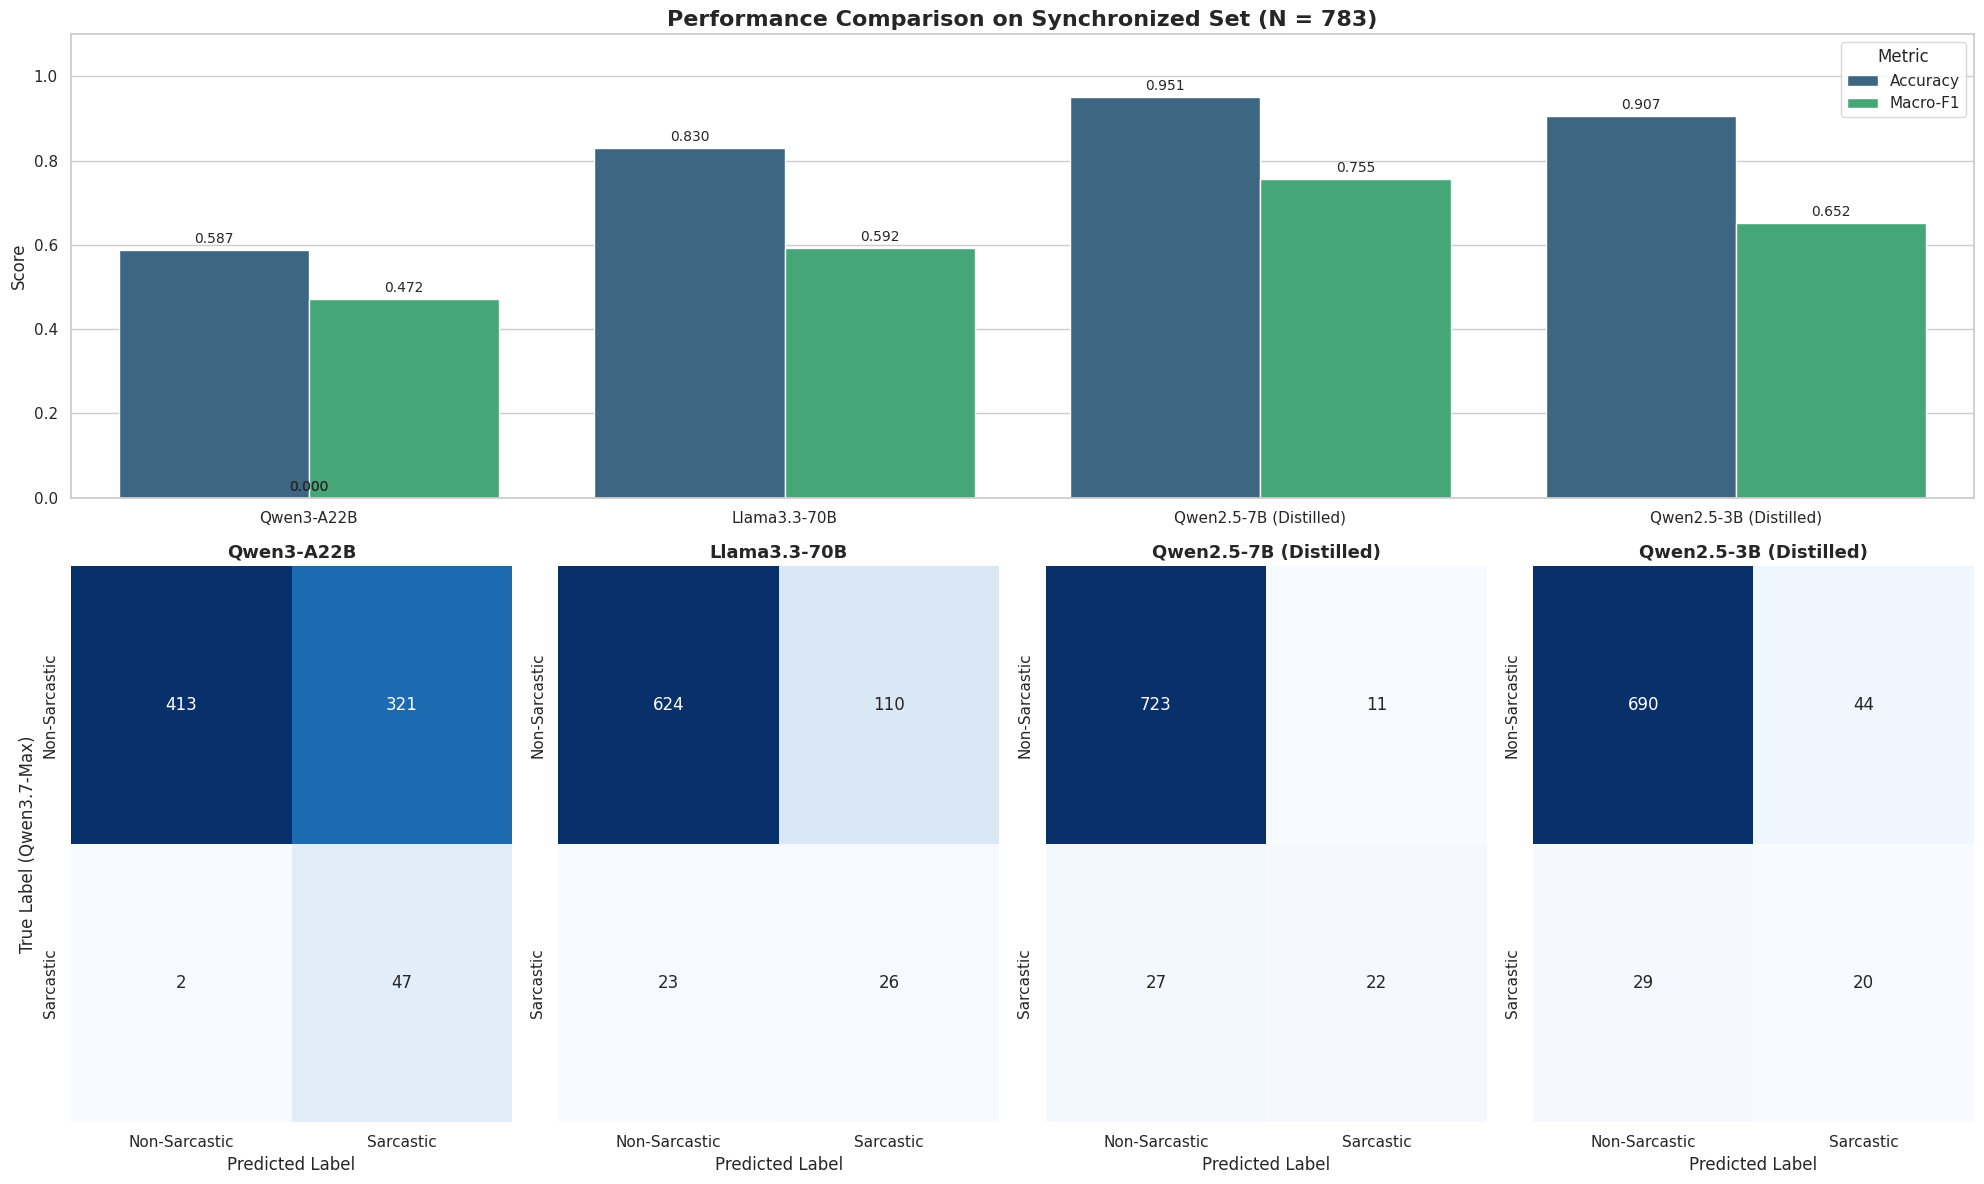

In [39]:
sns.set_theme(style="whitegrid")
num_models = len(MODELS_TO_EVALUATE)

if final_sample_count > 0:
    fig = plt.figure(figsize=(5 * num_models, 12))
    gs = fig.add_gridspec(2, num_models, height_ratios=[1, 1.2])

    # --- Vùng 1: Barplot ---
    ax_bar = fig.add_subplot(gs[0, :])
    df_melted = df_report.melt(id_vars=["Model"], value_vars=["Accuracy", "Macro-F1"], 
                               var_name="Metric", value_name="Score")

    sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", ax=ax_bar, palette="viridis")
    ax_bar.set_title(f"Performance Comparison on Synchronized Set (N = {final_sample_count})", 
                     fontsize=16, fontweight='bold')
    ax_bar.set_ylim(0, 1.1)
    ax_bar.set_ylabel("Score", fontsize=12)
    ax_bar.set_xlabel("")

    # Thêm text chỉ số lên đỉnh cột
    for p in ax_bar.patches:
        ax_bar.annotate(format(p.get_height(), '.3f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha = 'center', va = 'center', xytext = (0, 8), 
                        textcoords = 'offset points', fontsize=10)

    # --- Vùng 2: Confusion Matrices ---
    for i, model_name in enumerate(MODELS_TO_EVALUATE.keys()):
        ax_cm = fig.add_subplot(gs[1, i])
        
        y_pred = df_master[f"pred_{model_name}"]
        cm = confusion_matrix(y_true, y_pred, labels=labels_list)
        
        sns.heatmap(cm, annot=True, fmt='g', cmap="Blues", cbar=False, 
                    xticklabels=labels_list, yticklabels=labels_list, ax=ax_cm)
        
        ax_cm.set_title(f"{model_name}", fontsize=13, fontweight='bold')
        ax_cm.set_xlabel('Predicted Label')
        if i == 0:
            ax_cm.set_ylabel('True Label (Qwen3.7-Max)')

    plt.tight_layout()
    plt.savefig("benchmark_evaluation_synchronized_plot.png", dpi=300, bbox_inches='tight')
    print("\n(Đã lưu biểu đồ vào benchmark_evaluation_synchronized_plot.png)")
    plt.show()
else:
    print("\nKhông có sample nào chung giữa tất cả các file. Vui lòng kiểm tra lại data.")

1. Tải Ground Truth từ: /home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/data/gold/gold_Qwen3.7_max.csv
2. Tải tập Anchor (Chuẩn đồng bộ) từ: /home/check/DATA/university/yr3, hk2/IE403 - Khai thác dữ liệu truyền thông xã hội/Project/model/eval/test_result_7B.csv
-> Số sample cơ sở (GT giao với 7B sau khi lọc trùng): 783
-> Đã đồng bộ Qwen3-A22B. Số sample hiện tại: 783
-> Đã đồng bộ Llama3.3-70B. Số sample hiện tại: 783
-> Đã đồng bộ Qwen2.5-7B (Distilled). Số sample hiện tại: 783
-> Đã đồng bộ Qwen2.5-3B (Distilled). Số sample hiện tại: 783

=> ĐỒNG BỘ HOÀN TẤT. Tổng số sample dùng để test: 783

 BENCHMARK EVALUATION REPORT (Strictly Synchronized Test Set)
                 Model  Accuracy  Macro-F1  Macro-Precision  Macro-Recall  Matched_Samples
            Qwen3-A22B  0.587484  0.472153         0.561449      0.760927              783
          Llama3.3-70B  0.830140  0.592387         0.577814      0.690374              783
Qwen2.5-7B (Distill

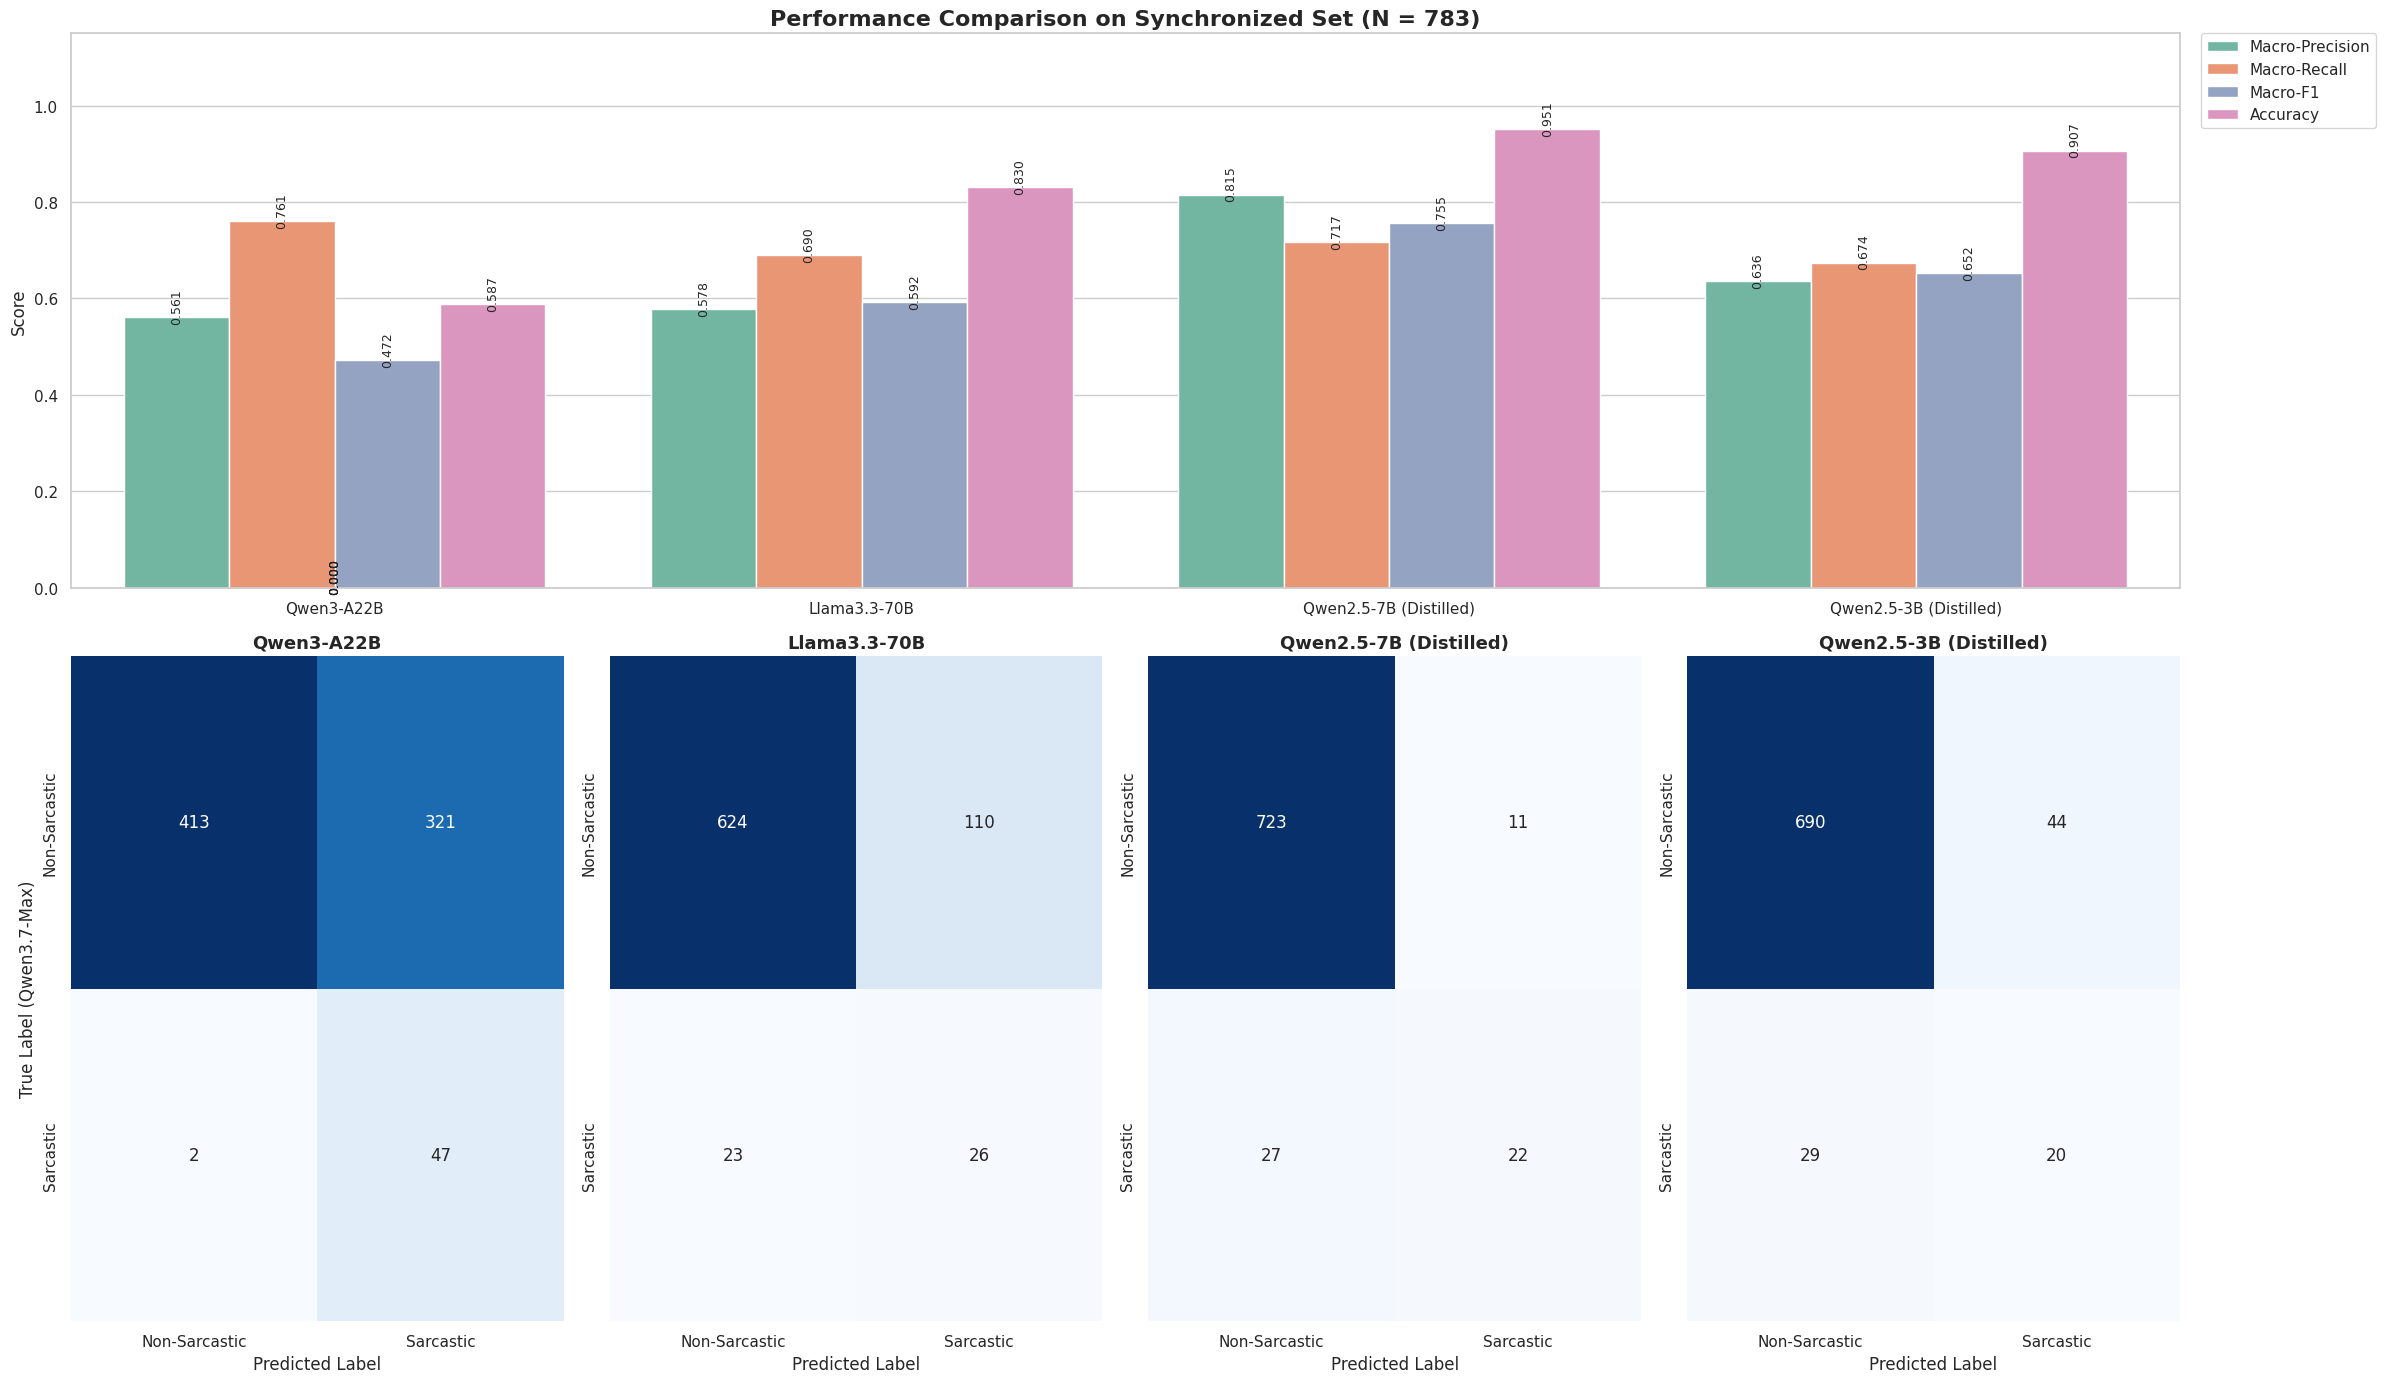

In [5]:
print(f"1. Tải Ground Truth từ: {GT_FILE}")
df_gt = pd.read_csv(GT_FILE)[MATCH_KEYS + [GT_LABEL_COL]].rename(columns={GT_LABEL_COL: 'gt_label'})
df_gt.dropna(subset=['gt_label'], inplace=True)
df_gt = df_gt.drop_duplicates(subset=MATCH_KEYS, keep='first') 

print(f"2. Tải tập Anchor (Chuẩn đồng bộ) từ: {ANCHOR_FILE}")
df_anchor = pd.read_csv(ANCHOR_FILE)[MATCH_KEYS]
df_anchor = df_anchor.drop_duplicates(subset=MATCH_KEYS, keep='first')

df_master = pd.merge(df_gt, df_anchor, on=MATCH_KEYS, how='inner')
print(f"-> Số sample cơ sở (GT giao với 7B sau khi lọc trùng): {len(df_master)}")

for model_name, config in MODELS_TO_EVALUATE.items():
    file_path = config["file"]
    label_col = config["label_col"]
    
    try:
        df_model = pd.read_csv(file_path)[MATCH_KEYS + [label_col]]
        pred_col_name = f"pred_{model_name}"
        df_model = df_model.rename(columns={label_col: pred_col_name})
        df_model.dropna(subset=[pred_col_name], inplace=True)
        
        df_model = df_model.drop_duplicates(subset=MATCH_KEYS, keep='first')
        
        df_master = pd.merge(df_master, df_model, on=MATCH_KEYS, how='inner')
        print(f"-> Đã đồng bộ {model_name}. Số sample hiện tại: {len(df_master)}")
        
    except Exception as e:
        print(f"-> Lỗi khi xử lý {model_name} ({file_path}): {e}")

final_sample_count = len(df_master)
print(f"\n=> ĐỒNG BỘ HOÀN TẤT. Tổng số sample dùng để test: {final_sample_count}")

all_labels = set(df_master['gt_label'].unique())
for model_name in MODELS_TO_EVALUATE.keys():
    all_labels.update(df_master[f"pred_{model_name}"].unique())
labels_list = sorted(list(all_labels))

# ==========================================
# 3. TÍNH TOÁN METRICS VÀ XUẤT BÁO CÁO
# ==========================================
evaluation_results = []
y_true = df_master['gt_label']

for model_name in MODELS_TO_EVALUATE.keys():
    y_pred = df_master[f"pred_{model_name}"]
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    # 2. TÍNH TOÁN THÊM PRECISION VÀ RECALL (Dùng Macro average)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro-F1": f1_macro,
        "Macro-Precision": precision_macro,
        "Macro-Recall": recall_macro,
        "Matched_Samples": final_sample_count
    })

df_report = pd.DataFrame(evaluation_results)
print("\n" + "="*80)
print(" BENCHMARK EVALUATION REPORT (Strictly Synchronized Test Set)")
print("="*80)
print(df_report.to_string(index=False))
df_report.to_csv("benchmark_report_synchronized.csv", index=False)

# ==========================================
# 4. VISUALIZATION (BARPLOT & CONFUSION MATRIX)
# ==========================================
sns.set_theme(style="whitegrid")
num_models = len(MODELS_TO_EVALUATE)

if final_sample_count > 0:
    fig = plt.figure(figsize=(6 * num_models, 14)) # Tăng nhẹ kích thước figure để có chỗ cho 4 cột bar
    gs = fig.add_gridspec(2, num_models, height_ratios=[1, 1.2])

    # --- Vùng 1: Barplot ---
    ax_bar = fig.add_subplot(gs[0, :])
    
    # 3. CẬP NHẬT value_vars ĐỂ VẼ CÁC METRIC MỚI
    # (Nếu chỉ muốn vẽ Precision và Recall, bạn xóa "Accuracy" và "Macro-F1" khỏi list này)
    metrics_to_plot = ["Macro-Precision", "Macro-Recall", "Macro-F1", "Accuracy"]
    
    df_melted = df_report.melt(id_vars=["Model"], value_vars=metrics_to_plot, 
                               var_name="Metric", value_name="Score")

    # Vẽ biểu đồ
    sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", ax=ax_bar, palette="Set2") # Đổi palette cho màu sắc tách bạch hơn
    ax_bar.set_title(f"Performance Comparison on Synchronized Set (N = {final_sample_count})", 
                     fontsize=16, fontweight='bold')
    ax_bar.set_ylim(0, 1.15) # Tăng nhẹ trục Y để số trên đỉnh cột không bị cắt
    ax_bar.set_ylabel("Score", fontsize=12)
    ax_bar.set_xlabel("")
    
    # Đưa chú thích (Legend) ra ngoài để không đè lên các cột bar
    ax_bar.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)

    # Thêm text chỉ số lên đỉnh cột
    for p in ax_bar.patches:
        ax_bar.annotate(format(p.get_height(), '.3f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha = 'center', va = 'center', xytext = (0, 8), 
                        textcoords = 'offset points', fontsize=9, rotation=90) # Xoay dọc số liệu nếu 4 cột quá sát nhau

    # --- Vùng 2: Confusion Matrices ---
    for i, model_name in enumerate(MODELS_TO_EVALUATE.keys()):
        ax_cm = fig.add_subplot(gs[1, i])
        
        y_pred = df_master[f"pred_{model_name}"]
        cm = confusion_matrix(y_true, y_pred, labels=labels_list)
        
        sns.heatmap(cm, annot=True, fmt='g', cmap="Blues", cbar=False, 
                    xticklabels=labels_list, yticklabels=labels_list, ax=ax_cm)
        
        ax_cm.set_title(f"{model_name}", fontsize=13, fontweight='bold')
        ax_cm.set_xlabel('Predicted Label')
        if i == 0:
            ax_cm.set_ylabel('True Label (Qwen3.7-Max)')

    plt.tight_layout()
    plt.savefig("benchmark_evaluation_metrics_plot.png", dpi=300, bbox_inches='tight')
    print("\n(Đã lưu biểu đồ vào benchmark_evaluation_metrics_plot.png)")
    plt.show()
else:
    print("\nKhông có sample nào chung giữa tất cả các file. Vui lòng kiểm tra lại data.")